In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion
from delta_hedge import DeltaHedgingEngine

In [4]:
start = 5
end = 200
n_pts = ((end - start) // start) + 1
x_axis = np.linspace(start, end, n_pts)

spot = 100 # $100
strike = 100 # $100
maturity = 1 # 1 year
rate = 0.05 # 5%
sigma = 0.2 # 20%
drift = 0.3 # 30%

underlying = GeometricBrownianMotion(spot, drift, sigma)

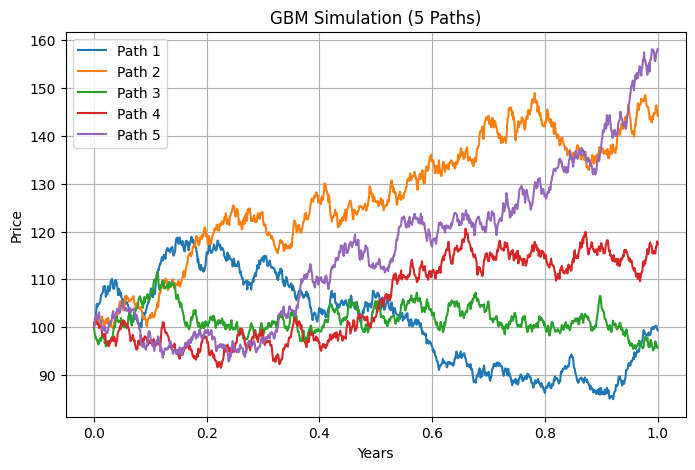

In [5]:
mesh = 1/1000
runs = 5

paths = underlying.simulate(maturity, runs, mesh)

time_grid = np.linspace(0, maturity, len(paths[0]))
plt.figure(figsize=(8,5))
for i in range(runs):
    plt.plot(time_grid, paths[i], label=f'Path {i+1}')

plt.title(f'GBM Simulation ({runs} Paths)')
plt.xlabel('Years')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

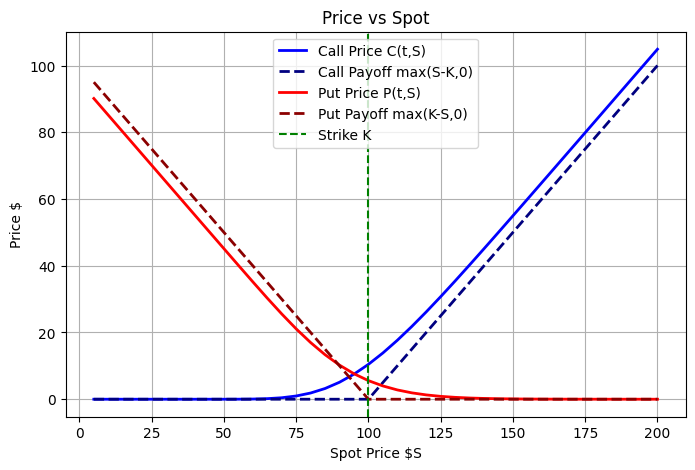

In [6]:
call = CallOption(strike, maturity)
put = PutOption(strike, maturity)

plt.figure(figsize=(8,5))
plt.plot(x_axis, call.price(x_axis, 0, rate, sigma), color='blue', label='Call Price C(t,S)', linewidth=2)
plt.plot(x_axis, call.payoff(x_axis), '--', color='navy', label='Call Payoff max(S-K,0)', linewidth=2)
plt.plot(x_axis, put.price(x_axis, 0, rate, sigma), color='red', label='Put Price P(t,S)', linewidth=2)
plt.plot(x_axis, put.payoff(x_axis), '--', color='darkred', label='Put Payoff max(K-S,0)', linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label='Strike K')
plt.xlabel('Spot Price $S')
plt.ylabel('Price $')
plt.title('Price vs Spot')
plt.legend()
plt.grid(True)

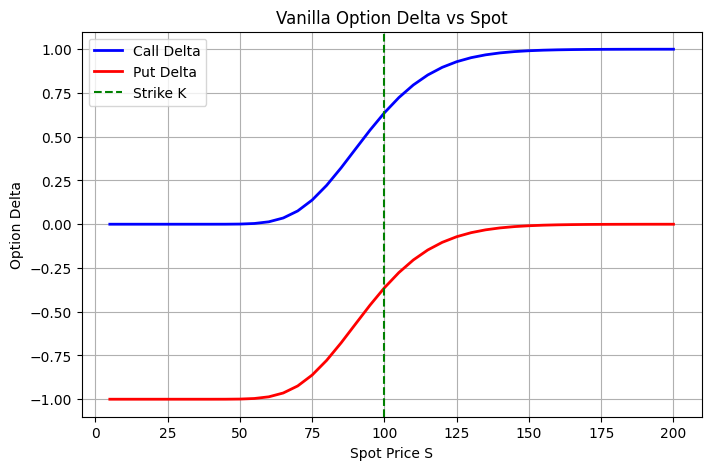

In [7]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, call.delta(x_axis, 0, rate, sigma), color='blue', label='Call Delta', linewidth=2)
plt.plot(x_axis, put.delta(x_axis, 0, rate, sigma), color='red', label='Put Delta', linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Delta')
plt.title('Vanilla Option Delta vs Spot')
plt.legend()
plt.grid(True)

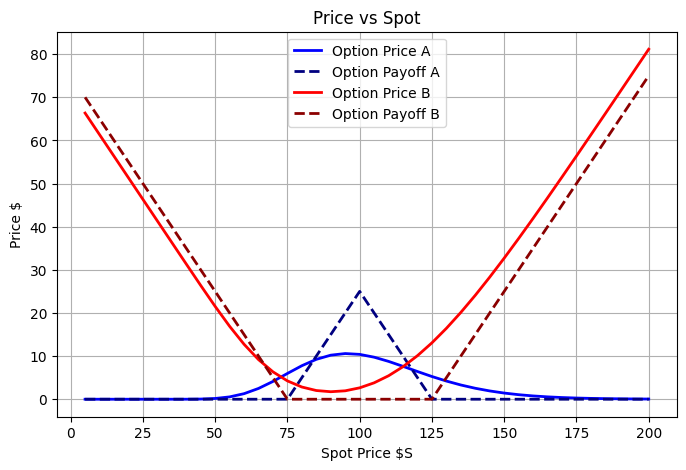

In [8]:
bull_call = CallOption(90,1) - CallOption(110,1)
butterfly = CallOption(75, 1) - 2*CallOption(100, 1) + CallOption(125, 1)
condor = PutOption(50,1) - PutOption(60,1) - CallOption(140,1) + CallOption(150,1)
straddle = CallOption(100,1) + PutOption(100,1)
strangle = CallOption(125,1) + PutOption(75,1)

combo_option_1 = butterfly
combo_option_2 = strangle

plt.figure(figsize=(8,5))
plt.plot(x_axis, combo_option_1.price(x_axis, 0, rate, sigma), color='blue', label='Option Price A', linewidth=2)
plt.plot(x_axis, combo_option_1.payoff(x_axis), '--', color='navy', label='Option Payoff A', linewidth=2)
plt.plot(x_axis, combo_option_2.price(x_axis, 0, rate, sigma), color='red', label='Option Price B', linewidth=2)
plt.plot(x_axis, combo_option_2.payoff(x_axis), '--', color='darkred', label='Option Payoff B', linewidth=2)
plt.xlabel('Spot Price $S')
plt.ylabel('Price $')
plt.title('Price vs Spot')
plt.legend()
plt.grid(True)

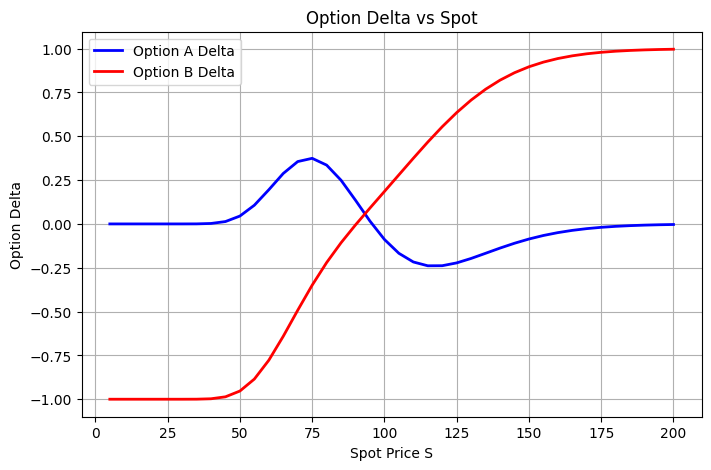

In [9]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, combo_option_1.delta(x_axis, 0, rate, sigma), color='blue', label='Option A Delta', linewidth=2)
plt.plot(x_axis, combo_option_2.delta(x_axis, 0, rate, sigma), color='red', label='Option B Delta', linewidth=2)
plt.xlabel('Spot Price S')
plt.ylabel('Option Delta')
plt.title('Option Delta vs Spot')
plt.legend()
plt.grid(True)

In [10]:
mesh = 1/10
runs = 1000
path_index = 0
override_threshold = 1024

hedging_results = DeltaHedgingEngine(call, underlying, override_threshold).run(rate, sigma, runs, mesh)

print(np.mean(hedging_results.pnl))
print(np.std(hedging_results.pnl))

-2.3761100803480804
16.29831906172271


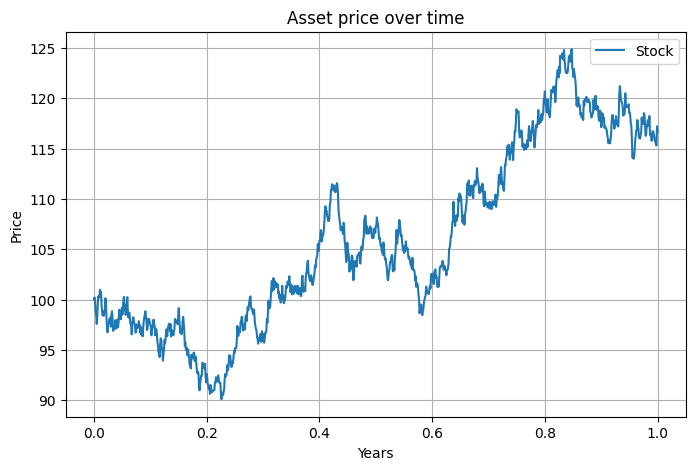

In [11]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.underlying[path_index], label=f'Stock')

plt.title('Asset price over time')
plt.xlabel('Years')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

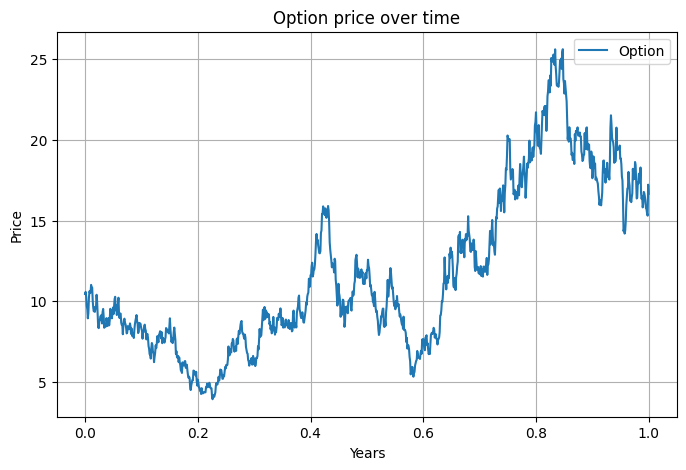

In [12]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.option[path_index], label=f'Option')

plt.title('Option price over time')
plt.xlabel('Years')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

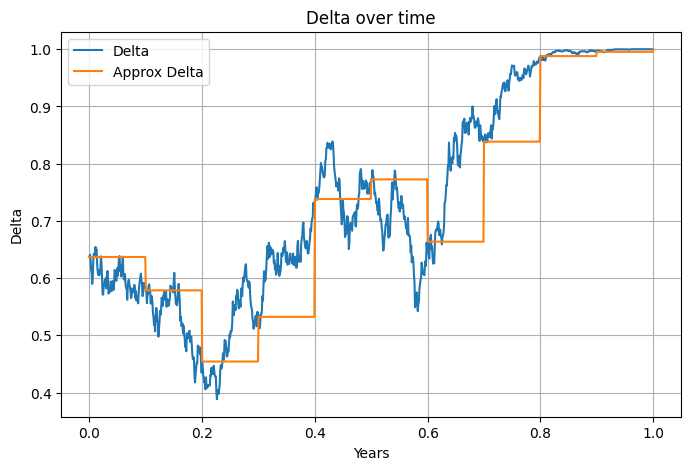

In [13]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.true_delta[path_index], label=f'Delta')
plt.plot(hedging_results.time, hedging_results.approx_delta[path_index], label=f'Approx Delta')

plt.title('Delta over time')
plt.xlabel('Years')
plt.ylabel('Delta')
plt.legend()
plt.grid(True)

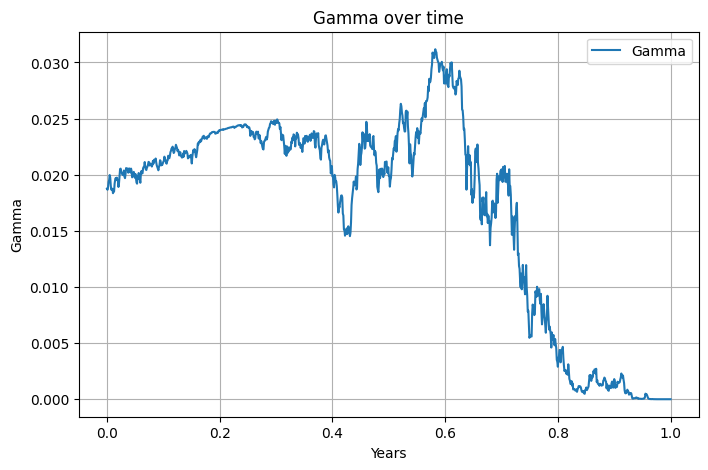

In [14]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.gamma[path_index], label=f'Gamma')

# gamma tend to zero at maturity if the option is deep ITM/OTM. gamma blows up at maturity if ATM.
plt.title('Gamma over time')
plt.xlabel('Years')
plt.ylabel('Gamma')
plt.legend()
plt.grid(True)

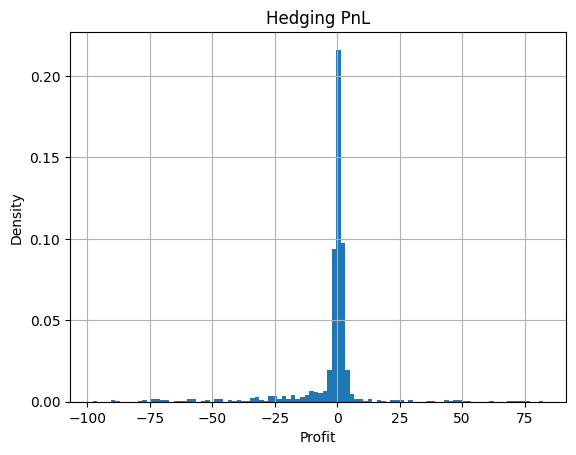

In [15]:
plt.hist(hedging_results.pnl, bins=100, density=True)

plt.title('Hedging PnL')
plt.xlabel('Profit')
plt.ylabel('Density')
plt.grid(True)

In [32]:
dt_arr = 1 / (2 ** np.arange(10))
runs = 1000
path_index = 0
override_threshold = 1024

pnl_var = []

for dt in dt_arr:
    hedging_results = DeltaHedgingEngine(call, underlying, override_threshold).run(rate, sigma, runs, dt)
    pnl_var.append(np.var(hedging_results.pnl))

pnl_var = [float(_) for _ in pnl_var]

In [33]:
dt_values = np.array(dt_arr)
var_values = np.array(pnl_var)

log_dt = np.log(dt_values)
log_var = np.log(var_values)

# Linear regression
slope, intercept = np.polyfit(log_dt, log_var, 1)

print("Estimated convergence rate:", slope)

Estimated convergence rate: 0.5256421348608737


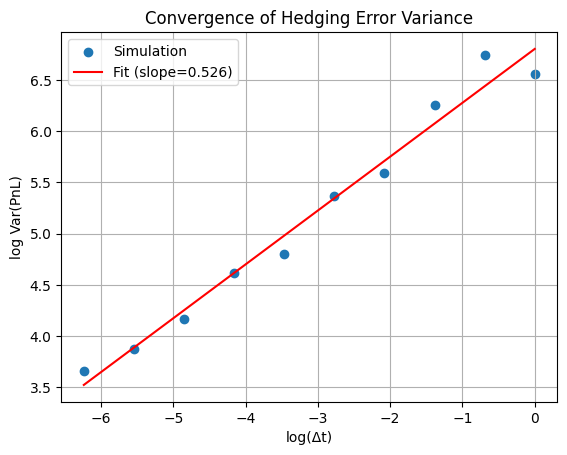

In [34]:
plt.scatter(log_dt, log_var, label="Simulation")

plt.plot(
    log_dt,
    slope*log_dt + intercept,
    color='red',
    label=f"Fit (slope={slope:.3f})"
)

plt.xlabel("log(Δt)")
plt.ylabel("log Var(PnL)")
plt.legend()
plt.title("Convergence of Hedging Error Variance")
plt.grid(True)

$\text{Var(PnL)} \propto \Delta t$

so

$\log(\text{Var}) = \log(C) + 1 \cdot \log(\Delta t)$

Meaning:

> On a log–log plot, slope ≈ 1